In [6]:
import numpy as np


class MinimumJerkInterpolator:
    """
    Implements a minimum jerk trajectory for smooth interpolation with guaranteed arrival time.
    Useful for hyperparameter scheduling in ML, especially curriculum learning.
    """

    def __init__(self, initial_value=0.0, initial_velocity=0.0, initial_acceleration=0.0):
        """
        Initialize the interpolator with starting conditions.

        Args:
            initial_value: Starting value
            initial_velocity: Starting velocity (rate of change)
            initial_acceleration: Starting acceleration (optional, default 0)
        """
        self.value = initial_value
        self.velocity = initial_velocity
        self.acceleration = initial_acceleration

        self.target = initial_value
        self.duration = 1.0  # Default duration in seconds/steps
        self.start_time = None
        self.coeffs = None

    def _calculate_coefficients(self, y0, v0, a0, y1, v1, a1, T):
        """
        Calculate the coefficients for the 5th-degree polynomial.

        Args:
            y0: Initial position
            v0: Initial velocity
            a0: Initial acceleration
            y1: Target position
            v1: Target velocity (typically 0)
            a1: Target acceleration (typically 0)
            T: Duration

        Returns:
            List of 6 coefficients [c0, c1, c2, c3, c4, c5]
        """
        # First 3 coefficients are determined by initial conditions
        c0 = y0
        c1 = v0
        c2 = a0 / 2.0

        # Set up the system of equations for the remaining coefficients
        T2 = T * T
        T3 = T2 * T
        T4 = T3 * T
        T5 = T4 * T

        # Right-hand side of the equation
        b1 = y1 - y0 - v0 * T - (a0 / 2.0) * T2
        b2 = v1 - v0 - a0 * T
        b3 = a1 - a0

        # Coefficient matrix
        A = np.array([[T3, T4, T5], [3 * T2, 4 * T3, 5 * T4], [6 * T, 12 * T2, 20 * T3]])

        b = np.array([b1, b2, b3])

        # Solve the system of equations
        x = np.linalg.solve(A, b)

        # Extract the coefficients
        c3, c4, c5 = x

        return [c0, c1, c2, c3, c4, c5]

    def set_target(self, target, duration=None, reset_time=True):
        """
        Set a new target value and recalculate the trajectory.

        Args:
            target: The new target value to reach
            duration: The time/steps to reach the target (if None, use current duration)
            reset_time: Whether to reset the timer (default True)

        Returns:
            self for chaining
        """
        if duration is not None:
            self.duration = duration

        if reset_time:
            self.start_time = 0.0

        # Calculate coefficients for minimum jerk trajectory
        self.coeffs = self._calculate_coefficients(
            y0=self.value,
            v0=self.velocity,
            a0=self.acceleration,
            y1=target,
            v1=0.0,  # Target velocity (typically zero)
            a1=0.0,  # Target acceleration (typically zero)
            T=self.duration,
        )

        self.target = target
        return self

    def update(self, t=None):
        """
        Update the current value based on the time parameter.

        Args:
            t: Current time/step (if None, increments internal time)

        Returns:
            Current value
        """
        if self.coeffs is None:
            return self.value

        if self.start_time is None:
            self.start_time = 0.0 if t is None else t

        # Calculate elapsed time
        if t is None:
            t = self.start_time + 1.0  # Increment by 1 if no time provided
            self.start_time = t

        elapsed = t - self.start_time

        # Clamp to duration
        if elapsed >= self.duration:
            self.value = self.target
            self.velocity = 0.0
            self.acceleration = 0.0
            return self.value

        # Calculate position using the polynomial
        c0, c1, c2, c3, c4, c5 = self.coeffs
        self.value = c0 + c1 * elapsed + c2 * elapsed**2 + c3 * elapsed**3 + c4 * elapsed**4 + c5 * elapsed**5

        # Calculate velocity (first derivative)
        self.velocity = c1 + 2 * c2 * elapsed + 3 * c3 * elapsed**2 + 4 * c4 * elapsed**3 + 5 * c5 * elapsed**4

        # Calculate acceleration (second derivative)
        self.acceleration = 2 * c2 + 6 * c3 * elapsed + 12 * c4 * elapsed**2 + 20 * c5 * elapsed**3

        return self.value

    def get_value_at(self, t):
        """
        Get the interpolated value at a specific time without changing internal state.

        Args:
            t: Time to evaluate

        Returns:
            The value at time t
        """
        if self.coeffs is None or self.start_time is None:
            return self.value

        elapsed = t - self.start_time

        # Clamp to duration
        if elapsed >= self.duration:
            return self.target

        # Calculate using the polynomial
        c0, c1, c2, c3, c4, c5 = self.coeffs
        return c0 + c1 * elapsed + c2 * elapsed**2 + c3 * elapsed**3 + c4 * elapsed**4 + c5 * elapsed**5


<Figure size 1200x800 with 0 Axes>

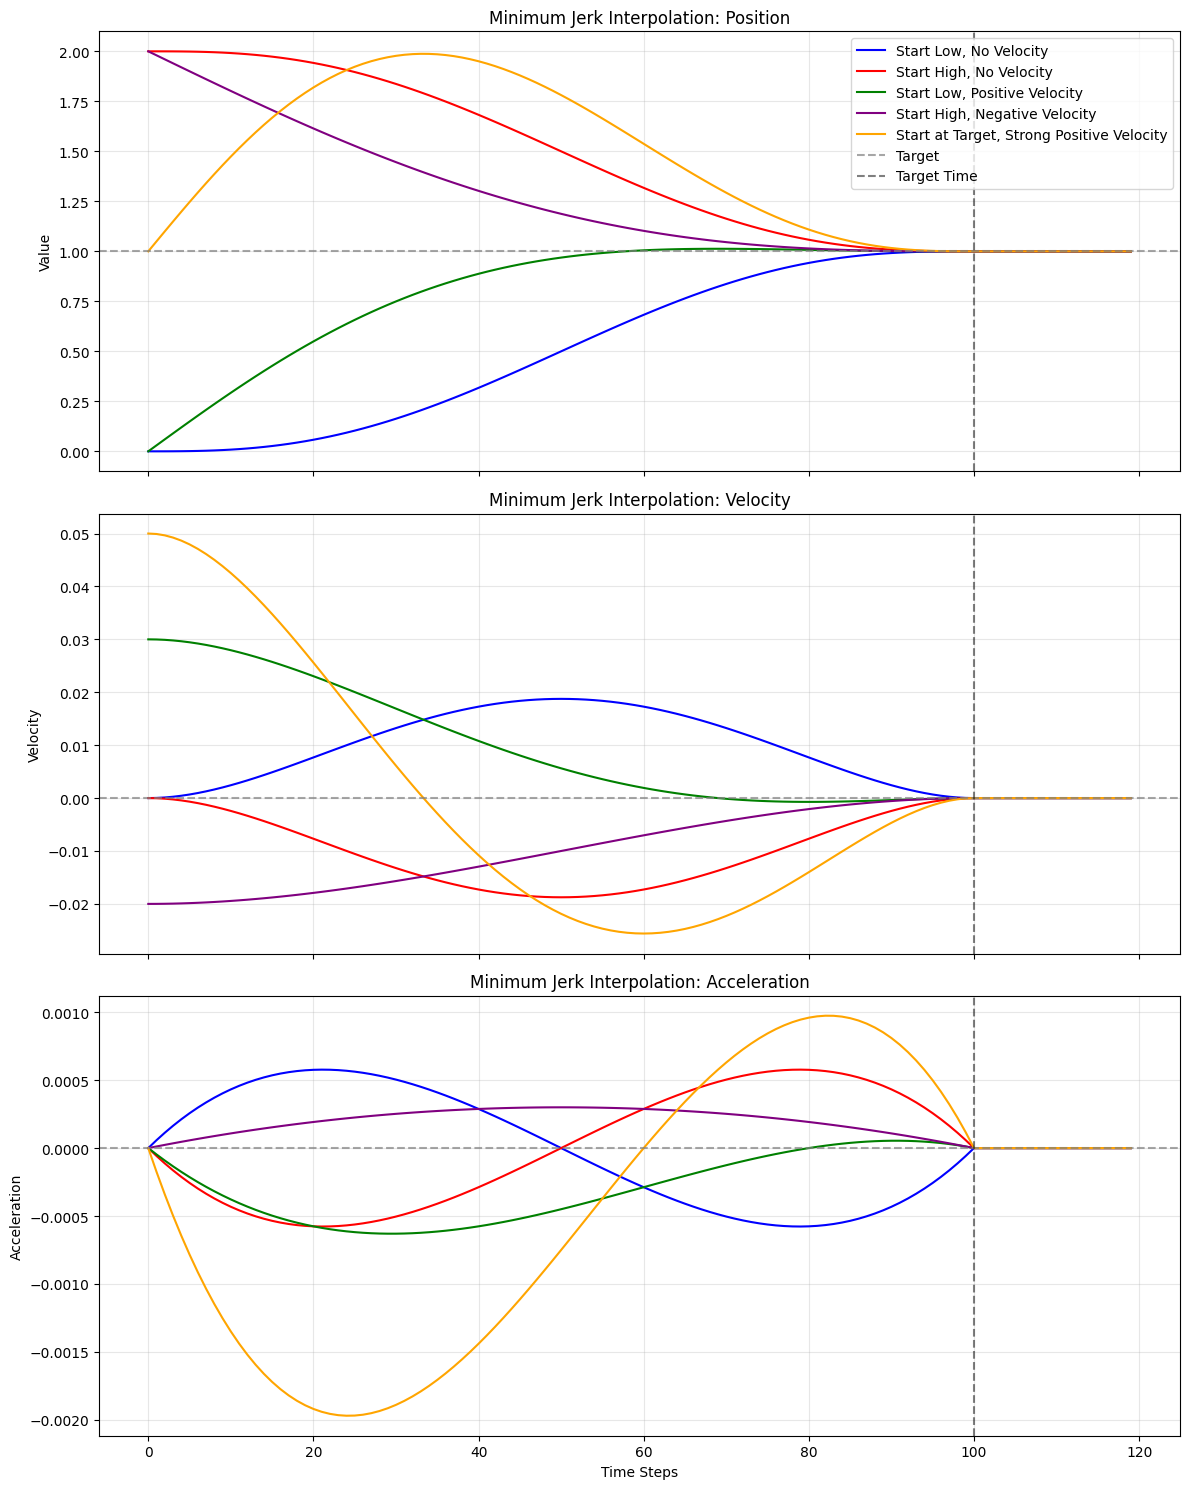

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


# Create a visualization of different interpolators converging
# Set up the plot
plt.figure(figsize=(12, 8))

# Define common parameters
target = 1.0  # All will converge to this value
duration = 100  # Steps to reach target

# Create interpolators with different initial conditions
interpolators = [
    {
        'name': 'Start Low, No Velocity',
        'interp': MinimumJerkInterpolator(initial_value=0.0, initial_velocity=0.0),
        'color': 'blue',
        'linestyle': '-',
    },
    {
        'name': 'Start High, No Velocity',
        'interp': MinimumJerkInterpolator(initial_value=2.0, initial_velocity=0.0),
        'color': 'red',
        'linestyle': '-',
    },
    {
        'name': 'Start Low, Positive Velocity',
        'interp': MinimumJerkInterpolator(initial_value=0.0, initial_velocity=0.03),
        'color': 'green',
        'linestyle': '-',
    },
    {
        'name': 'Start High, Negative Velocity',
        'interp': MinimumJerkInterpolator(initial_value=2.0, initial_velocity=-0.02),
        'color': 'purple',
        'linestyle': '-',
    },
    {
        'name': 'Start at Target, Strong Positive Velocity',
        'interp': MinimumJerkInterpolator(initial_value=1.0, initial_velocity=0.05),
        'color': 'orange',
        'linestyle': '-',
    },
]

# Set targets for all interpolators
for interp_info in interpolators:
    interp_info['interp'].set_target(target=target, duration=duration)

# Generate data for each interpolator
time_steps = np.arange(0, duration + 20)  # Add some extra steps to show stabilization
histories = {}

for interp_info in interpolators:
    name = interp_info['name']
    interp = interp_info['interp']

    # Record position, velocity, and acceleration
    positions = []
    velocities = []
    accelerations = []

    for t in time_steps:
        interp.update(t=t)
        positions.append(interp.value)
        velocities.append(interp.velocity)
        accelerations.append(interp.acceleration)

    histories[name] = {
        'positions': positions,
        'velocities': velocities,
        'accelerations': accelerations,
        'color': interp_info['color'],
        'linestyle': interp_info['linestyle'],
    }

# Create a three-panel plot: position, velocity, acceleration
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

# Plot position
for name, history in histories.items():
    ax1.plot(time_steps, history['positions'], color=history['color'], linestyle=history['linestyle'], label=name)

ax1.axhline(y=target, color='gray', linestyle='--', alpha=0.7, label='Target')
ax1.axvline(x=duration, color='black', linestyle='--', alpha=0.5, label='Target Time')
ax1.set_ylabel('Value')
ax1.set_title('Minimum Jerk Interpolation: Position')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')

# Plot velocity
for name, history in histories.items():
    ax2.plot(time_steps, history['velocities'], color=history['color'], linestyle=history['linestyle'], label=name)

ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
ax2.axvline(x=duration, color='black', linestyle='--', alpha=0.5)
ax2.set_ylabel('Velocity')
ax2.set_title('Minimum Jerk Interpolation: Velocity')
ax2.grid(True, alpha=0.3)

# Plot acceleration
for name, history in histories.items():
    ax3.plot(time_steps, history['accelerations'], color=history['color'], linestyle=history['linestyle'], label=name)

ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
ax3.axvline(x=duration, color='black', linestyle='--', alpha=0.5)
ax3.set_xlabel('Time Steps')
ax3.set_ylabel('Acceleration')
ax3.set_title('Minimum Jerk Interpolation: Acceleration')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

At step 30: value=0.3590, velocity=0.0142
Target changed to 0.8 with duration 70


<Figure size 1200x600 with 0 Axes>

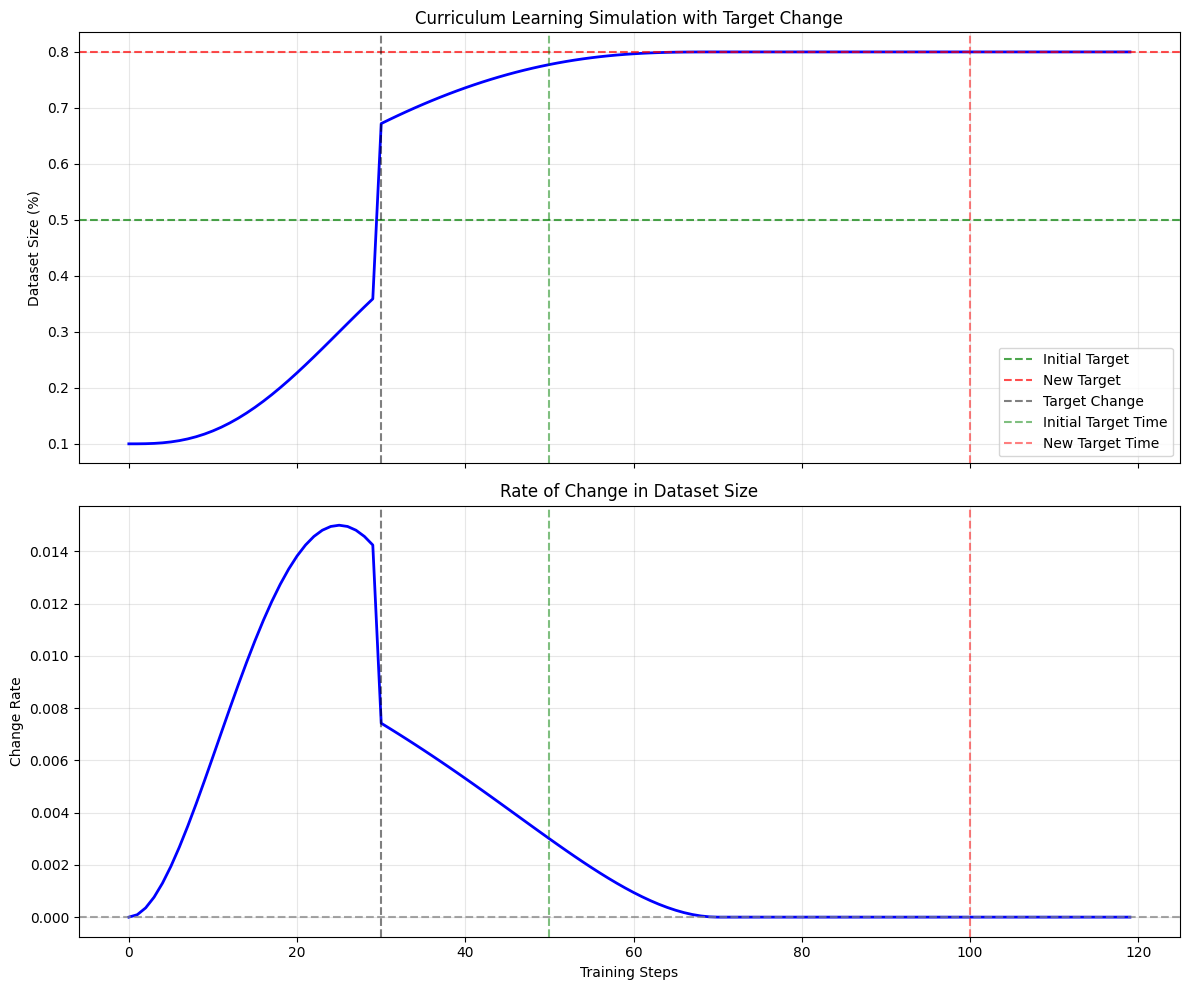

In [10]:

# Create an animated visualization to show real-time convergence
def create_animation():
    fig, ax = plt.subplots(figsize=(10, 6))

    # Set up plot
    ax.set_xlim(-10, duration + 30)
    ax.set_ylim(-0.5, 2.5)
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Value')
    ax.set_title('Minimum Jerk Interpolation Animation')
    ax.grid(True, alpha=0.3)

    # Target line
    ax.axhline(y=target, color='gray', linestyle='--', alpha=0.7, label='Target')
    ax.axvline(x=duration, color='black', linestyle='--', alpha=0.5, label='Target Time')

    # Initialize lines and points
    lines = []
    points = []

    for interp_info in interpolators:
        (line,) = ax.plot([], [], color=interp_info['color'], label=interp_info['name'])
        (point,) = ax.plot([], [], 'o', color=interp_info['color'], markersize=8)
        lines.append(line)
        points.append(point)

    ax.legend(loc='upper right')

    def init():
        for line, point in zip(lines, points):
            line.set_data([], [])
            point.set_data([], [])
        return lines + points

    def animate(frame):
        for i, interp_info in enumerate(interpolators):
            # Get history up to current frame
            positions = histories[interp_info['name']]['positions'][: frame + 1]
            times = time_steps[: frame + 1]

            # Update line
            lines[i].set_data(times, positions)

            # Update current point
            if frame < len(time_steps):
                points[i].set_data(times[-1], positions[-1])

        return lines + points

    anim = FuncAnimation(fig, animate, frames=len(time_steps), init_func=init, blit=True, interval=50)

    return anim


# Uncomment to show animation
# anim = create_animation()
# plt.show()

# Create a second plot focusing on a specific use case: curriculum learning
# with mid-trajectory target changes

plt.figure(figsize=(12, 6))

# Create interpolator for curriculum learning simulation
curriculum = MinimumJerkInterpolator(initial_value=0.1)  # Start with 10% of dataset
curriculum.set_target(target=0.5, duration=50)  # Initially plan to go to 50%

positions = []
velocities = []
time_steps = np.arange(0, 120)

# Simulate curriculum with a target change midway
for t in time_steps:
    # Change target at step 30
    if t == 30:
        current_value = curriculum.value
        current_velocity = curriculum.velocity
        print(f'At step 30: value={current_value:.4f}, velocity={current_velocity:.4f}')
        # curriculum.set_target(target=0.8, duration=70, reset_time=False)
        curriculum.set_target(target=0.8, duration=70, reset_time=False)
        print('Target changed to 0.8 with duration 70')

    curriculum.update(t=t)
    positions.append(curriculum.value)
    velocities.append(curriculum.velocity)

# Plot curriculum progression
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot positions
ax1.plot(time_steps, positions, color='blue', linewidth=2)
ax1.axhline(y=0.5, color='green', linestyle='--', alpha=0.7, label='Initial Target')
ax1.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='New Target')
ax1.axvline(x=30, color='black', linestyle='--', alpha=0.5, label='Target Change')
ax1.axvline(x=50, color='green', linestyle='--', alpha=0.5, label='Initial Target Time')
ax1.axvline(x=100, color='red', linestyle='--', alpha=0.5, label='New Target Time')
ax1.set_ylabel('Dataset Size (%)')
ax1.set_title('Curriculum Learning Simulation with Target Change')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')

# Plot velocities
ax2.plot(time_steps, velocities, color='blue', linewidth=2)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
ax2.axvline(x=30, color='black', linestyle='--', alpha=0.5)
ax2.axvline(x=50, color='green', linestyle='--', alpha=0.5)
ax2.axvline(x=100, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Training Steps')
ax2.set_ylabel('Change Rate')
ax2.set_title('Rate of Change in Dataset Size')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()